# Прогнозирование платежей с применением ансамбля моделей на реальных данных

Прогнозируем суммы платежей на агрегированных данных на следующие день/неделю/месяц с учетом отобранных и протестированных методов обработки данных и обучения моделей.

Данные подготовлены для прогнозирования сумм исходя из описательных признаков c учетом временной составляющей с применением трех моделей: LSTM, SARIMAX, Catboost и последующим взвешиванием прогнозов.

<a id='К-содержанию'></a>
**Содержание проекта** 
- [Загрузка и предобработка данных](#Загрузка-и-предобработка-данных)
- [Подготовка данных, агрегирование и генерация доппризнаков для прогнозирования сумм платежей](#Подготовка-данных,-агрегирование-и-генерация-доппризнаков-для-прогнозирования-сумм-платежей)
- [LSTM](#LSTM-подготовка-данных)  
    - [Подготовка данных](#LSTM-подготовка-данных)  
    - [Построение и обучение модели](#LSTM-построение-и-обучение-модели)  
    - [Валидация модели с визуализацией прогноза](#LSTM-валидация-модели-с-визуализацией-прогноза)  
- [SARIMAX](#SARIMAX-подготовка-данных)  
    - [Подготовка данных](#SARIMAX-подготовка-данных)  
    - [Построение и обучение модели](#SARIMAX-построение-и-обучение-модели)  
    - [Валидация модели с визуализацией прогноза](#SARIMAX-валидация-модели-с-визуализацией-прогноза)  
- [Catboost (+sarimax)](#Catboost-подготовка-данных)  
    - [Подготовка данных](#Catboost-подготовка-данных)  
    - [Построение и обучение модели](#Catboost-построение-и-обучение-модели)  
    - [Валидация модели с визуализацией прогноза](#Catboost-валидация-модели-с-визуализацией-прогноза)
- [Подбор модели ансамбля прогнозов на валидационной выборке](#Подбор-модели-ансамбля-прогнозов-на-валидационной-выборке)
- [Тестирование ансамбля прогнозов на тестовой выборке](#Тестирование-ансамбля-прогнозов-на-тестовой-выборке)


In [1]:
%%capture
!pip install torch
!pip install spacy
!python -m spacy download ru_core_news_sm

In [2]:
# 📦 стандартные библиотеки Python
import os
import random
import re
import pickle

# 🧮 научные и табличные библиотеки
import numpy as np
import pandas as pd

# 📊 визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# ⏳ прогресс-бары
from tqdm.notebook import tqdm

# 🧠 обработка текста и NLP
import spacy
nlp = spacy.load("ru_core_news_sm")
from transformers import AutoTokenizer, AutoModel

# 🤖 pyTorch
import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# 🛠 scikit-learn: пайплайны, препроцессинг, модели
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, ParameterGrid
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer
from sklearn.dummy import DummyRegressor

# 🧠 CatBoost
from catboost import CatBoostRegressor

# 📈 временные ряды
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 📉 PCA
from sklearn.decomposition import PCA

In [3]:
# вынесем блок с настройками и функциями

# зададим стандарт датафрейма перед загрузкой
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('future.no_silent_downcasting', True)


# устанавливаем фиксированное значение для всех случайных библиотек
RANDOM_STATE = 42

def seed_all(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False
seed_all(RANDOM_STATE)

# функция предобработки текста
def preprocess_text(text):
    # удаляем знаки пунктуации
    text = re.sub(r'[^\w\s]', ' ', text)
    # приводим к нижнему регистру
    text = text.lower()
    # делаем лемматизацию с использованием spaCy
    doc = nlp(text)
    text = " ".join([token.lemma_ for token in doc])
    return text

# задаем функцию для получения усредненного эмбеддинга текста
def get_embedding(text,tokenizer,model):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()


# cоздаём функцию и метрику SMAPE
def smape(y_true, y_pred):
    return 100 * np.mean(np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2))

smape_scorer = make_scorer(smape, greater_is_better=False)

# создаем функцию MASE
def mase(y_true, y_pred, y_train, seasonality=1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_train = np.asarray(y_train)
    scale = np.mean(np.abs(y_train[seasonality:] - y_train[:-seasonality]))
    return np.mean(np.abs(y_true - y_pred)) / scale

<a id='Загрузка-и-предобработка-данных'></a> 
## Загрузка и предобработка данных
[К содержанию](#К-содержанию)

In [4]:
# импортируем данные
pth1 = 'data_3.csv'
pth2 = 'users_actual.csv'

if os.path.exists(pth1) and os.path.exists(pth2):
    data_full = pd.read_csv(pth1)
    users_actual = pd.read_csv(pth2)
else:
    print('Something is wrong')

data_full.info()
display(data_full.head(2))
display(users_actual.head(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411434 entries, 0 to 411433
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  411434 non-null  int64  
 1   account_id                          411434 non-null  int64  
 2   contractor_id                       411434 non-null  int64  
 3   date                                411434 non-null  object 
 4   payments_amount                     411434 non-null  float64
 5   purpose                             410518 non-null  object 
 6   article_id                          411434 non-null  int64  
 7   project_id                          411434 non-null  int64  
 8   counterpartie_id                    411434 non-null  int64  
 9   donor_id                            411434 non-null  int64  
 10  robot_id                            411434 non-null  int64  
 11  donor_cat_id              

,id,account_id,contractor_id,date,payments_amount,purpose,article_id,project_id,counterpartie_id,donor_id,robot_id,donor_cat_id,accounts__id,accounts__user_id,articles__id,articles__user_id,articles__parent_id,projects__id,projects__user_id,projects__parent_id,counterparties__id,counterparties__user_id,counterparties__parent_id,robots__id,robots__user_id,article_alternative_names__user_id
0,6000,28,1210,2022-05-18,17500.00,"Оплата по договору об оказании услуг № 4 от 16.05.2022 за услуги по консультированию, НДС не облагается.",378,75,137,0,-1,135,28.00,41.00,378.00,41.00,376.00,75.00,41.00,17.00,135.00,41.00,133.00,NaN,NaN,41.00
1,6002,28,1210,2022-06-01,17500.00,"Оплата по договору об оказании услуг № 4 от 16.05.2022 за услуги по консультированию, НДС не облагается.",378,75,137,0,-1,135,28.00,41.00,378.00,41.00,376.00,75.00,41.00,17.00,135.00,41.00,133.00,NaN,NaN,41.00


,id
0,47
1,65


In [5]:
# проверяем Nan в user_id
display(data_full['accounts__user_id'].isna().sum())

# заполняем accounts__user_id значениями из других столбцов
data_full['accounts__user_id'] = (
    data_full['accounts__user_id']
    .fillna(data_full['articles__user_id'])
    .fillna(data_full['projects__user_id'])
    .fillna(data_full['counterparties__user_id'])
    .fillna(data_full['robots__user_id'])
    .fillna(data_full['article_alternative_names__user_id'])
)

# проверяем еще раз
display(data_full['accounts__user_id'].isna().sum())

21076

18840

In [6]:
# отфильтруем данные по актуальным пользователям и уберем технические поступления - возврат депозитов, переводы собственных средств
data_actual_id_wodepo = data_full[~data_full['purpose'].str.contains('вклад', na=False) & 
                             ~data_full['purpose'].str.contains('депози', na=False) &
                             ~data_full['purpose'].str.contains('собствен', na=False)&
                             ~data_full['purpose'].str.contains('процент', na=False)&
                             data_full['accounts__user_id'].isin(users_actual['id'])]

data_actual_id_wodepo['id'].count()

249513

In [7]:
# столбцы с дублирующими id, которые использовались при объединении данных при выгрузке из БД, также пустые столбцы и техстолбцы с одним значением
data = data_actual_id_wodepo.drop(['robot_id','accounts__id','articles__id','articles__user_id','projects__id','projects__user_id','counterparties__id',
                                   'counterparties__user_id','robots__user_id','article_alternative_names__user_id'], axis=1)


In [8]:
# поправим типы данных и заполним пропуски метками missing (для текстовых значений категорий) и 0 для пропущенных ID
data[['articles__parent_id','projects__parent_id','counterparties__parent_id','robots__id']] = data[['articles__parent_id','projects__parent_id','counterparties__parent_id','robots__id']].fillna(0).astype('int64')

data['purpose'] = data['purpose'].fillna('missing')

# конвертируем дату в datetime
data['date'] = pd.to_datetime(data['date'])

# переименуем и поправим тип столбца с фондами
data = data.rename(columns={'accounts__user_id': 'user_id'})
data['user_id'] = data['user_id'].fillna(0).astype('int64')

In [9]:
# закодируем текстовое поле
if os.path.exists("2try_data_with_purpose_mean.parquet"):
    data = pd.read_parquet("2try_data_with_purpose_mean.parquet")
else:
    tokenizer = AutoTokenizer.from_pretrained('DeepPavlov/rubert-base-cased')
    model = AutoModel.from_pretrained('DeepPavlov/rubert-base-cased')

    # предобработка текста
    tqdm.pandas(desc="Предобработка текстов")
    data["clean_purpose"] = data["purpose"].progress_apply(preprocess_text)

    # генерация эмбеддингов
    tqdm.pandas(desc="Генерация эмбеддингов")
    data["purpose_emb"] = data["clean_purpose"].progress_apply(lambda x: get_embedding(x, tokenizer, model))

    # 1. усредняем эмбеддинг в одно число
    data["purpose_mean"] = data["purpose_emb"].apply(lambda x: float(np.mean(x)))

    # 2. PCA на 5 главных компонентах
    purpose_vectors = np.vstack(data["purpose_emb"])
    pca = PCA(n_components=5,random_state=RANDOM_STATE)
    purpose_pca_features = pca.fit_transform(purpose_vectors)

    pca_column_names = [f"purpose_pca_{i+1}" for i in range(5)]
    data[pca_column_names] = purpose_pca_features

    # удаляем ненужные столбцы
    data.drop(columns=["purpose", "clean_purpose", "purpose_emb"], inplace=True)

    # сохраняем результат
    data.to_parquet("2try_data_with_purpose_mean.parquet", index=False)

In [10]:
# проверим дубликаты
print('Количество дубликатов: ', data.duplicated().sum().sum())
# проверим пропуски
print('Количество пропусков: ', data.isna().sum().sum())

data = data.drop('id', axis=1)  # удаляем id операции перед агрегированием

Количество дубликатов:  0
Количество пропусков:  0


In [11]:
# закодируем данные с поомщью frequency_encoding по каждому user_id
id_cols = [
    'account_id', 'contractor_id', 'article_id', 'project_id',
    'counterpartie_id', 'donor_id', 'donor_cat_id',
    'articles__parent_id', 'projects__parent_id',
    'counterparties__parent_id', 'robots__id'
]

data_fe = data.copy()

# создаем временный столбец с общим количеством записей для каждого пользователя
data_fe['user_total_counts_col'] = data_fe.groupby('user_id')['user_id'].transform('size')

# кодируем каждый из столбцов id_cols
for col in id_cols:
    
    encoded_col_name = f'{col}_ufreq' #задаем имя столбцу
    # считаем количество вхождений категории 'col' для данного 'user_id'
    numerator = data_fe.groupby(['user_id', col])[col].transform('size')
    # считаем долю и записываем в столбец
    data_fe[encoded_col_name] = numerator.astype(float) / data_fe['user_total_counts_col'].astype(float)

# удаляем временный столбец с общим количеством
data_fe.drop(columns=['user_total_counts_col'], inplace=True)


In [12]:
# агрегация платежей по дням и пользователям

# делаем список колонок для расчета nunique
nunique_cols = [
    'account_id', 'contractor_id', 'article_id', 'project_id',
    'counterpartie_id', 'donor_id', 'donor_cat_id',
    'articles__parent_id', 'projects__parent_id',
    'counterparties__parent_id', 'robots__id'
]

# делаем список колонок с кодированными значениями текстового поля
purpose_mean_cols = [
    'purpose_mean', 'purpose_pca_1', 'purpose_pca_2',
    'purpose_pca_3', 'purpose_pca_4', 'purpose_pca_5'
]

# делаем список кодированных категориальных колонок
col_ufreq = [col for col in data_fe.columns if col.endswith('_ufreq')]

# агрегируем данные до уровня дня
data_daily_agg = data_fe.groupby(['user_id', 'date']).agg(
    **{f'day_{col}_nunique': (col, 'nunique') for col in nunique_cols},
    
    day_payments_sum=('payments_amount', 'sum'),
    day_payments_count=('payments_amount', 'count'),
    day_min_payment=('payments_amount', 'min'),
    day_max_payment=('payments_amount', 'max'),
    
    **{f'day_{col}': (col, 'mean') for col in purpose_mean_cols},
    
    **{f'{col}_mean': (col, 'mean') for col in col_ufreq},
    **{f'{col}_std': (col, 'std') for col in col_ufreq},
                                                          
    ).reset_index()

# заполним NaN в std колонках нулями (там где было одно наблюдение/платеж)
std_cols = [col for col in data_daily_agg.columns if col.endswith('_std')]
data_daily_agg[std_cols] = data_daily_agg[std_cols].fillna(0)

In [13]:
# заполним пропущенные дни нулевыми значениями, чтобы сохранить структуру временного ряда

# создадим функцию
def fill_missing_dates(group):
    full_range = pd.date_range(group['date'].min(), group['date'].max(), freq='D')
    group = group.set_index('date').reindex(full_range)
    group['user_id'] = group['user_id'].iloc[0]
    return group.reset_index().rename(columns={'index': 'date'})

# применим эту функцию к каждой группе после группировки по user_id
data_daily_agg_filled = data_daily_agg.groupby('user_id', group_keys=False).apply(fill_missing_dates)

# заполним пропущенные значения нулями
data_daily_agg_filled = data_daily_agg_filled.fillna(0)


/var/folders/yf/tnhxwgts2035718d0nhj30rw0000gn/T/ipykernel_45499/3219682915.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_daily_agg_filled = data_daily_agg.groupby('user_id', group_keys=False).apply(fill_missing_dates)


In [14]:
# добавляем столбцы с днем недели и номером недели в месяце + кодируем их с помощью циклического кодирования (sin/cos)

# день недели (0 — понедельник, 6 — воскресенье)
data_daily_agg_filled['day_of_week'] = data_daily_agg_filled['date'].dt.weekday
data_daily_agg_filled['day_of_week_sin'] = np.sin(2 * np.pi * data_daily_agg_filled['day_of_week'] / 7)
data_daily_agg_filled['day_of_week_cos'] = np.cos(2 * np.pi * data_daily_agg_filled['day_of_week'] / 7)

# номер недели в месяце (1–5, 6 неделя скорее добавит шума,и вряд ли выучится хорошо)
data_daily_agg_filled['week_number'] = data_daily_agg_filled['date'].dt.day.sub(1).floordiv(7).add(1)
data_daily_agg_filled['week_number_sin'] = np.sin(2 * np.pi * data_daily_agg_filled['week_number'] / 5)
data_daily_agg_filled['week_number_cos'] = np.cos(2 * np.pi * data_daily_agg_filled['week_number'] / 5)

In [ ]:
# добавим по платежам скользящее среднее  и лаги за последние n дней (например, 7 дней), исключая текущий день
ROLLING_WINDOW = 7
LAGS = 8

def rolling_mean(group, rolling_window, lags):
    group = group.sort_values('date')
    group['rolling_day_payments'] = (group['day_payments_sum'].shift(1)
                                                 .rolling(window=rolling_window, min_periods=1)
                                                 .mean())
    for lag in range(1, lags):
        group[f'day_payments_sum_lag_{lag}'] = group['day_payments_sum'].shift(lag)
    
    return group

# применим эту функцию к каждой группе после группировки по user_id
data_daily_agg_filled_added = (
    data_daily_agg_filled
    .groupby('user_id', group_keys=False)
    .apply(lambda group: rolling_mean(group, rolling_window=ROLLING_WINDOW, lags=LAGS)))

data_daily_agg_filled_added = data_daily_agg_filled_added.fillna(0)
data_daily_agg_filled_added.head()


/var/folders/yf/tnhxwgts2035718d0nhj30rw0000gn/T/ipykernel_45499/438147222.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: rolling_mean(group, rolling_window=ROLLING_WINDOW, lags=LAGS)))


,date,user_id,day_account_id_nunique,day_contractor_id_nunique,day_article_id_nunique,day_project_id_nunique,day_counterpartie_id_nunique,day_donor_id_nunique,day_donor_cat_id_nunique,day_articles__parent_id_nunique,day_projects__parent_id_nunique,day_counterparties__parent_id_nunique,day_robots__id_nunique,day_payments_sum,day_payments_count,day_min_payment,day_max_payment,day_purpose_mean,day_purpose_pca_1,day_purpose_pca_2,day_purpose_pca_3,day_purpose_pca_4,day_purpose_pca_5,account_id_ufreq_mean,contractor_id_ufreq_mean,article_id_ufreq_mean,project_id_ufreq_mean,counterpartie_id_ufreq_mean,donor_id_ufreq_mean,donor_cat_id_ufreq_mean,articles__parent_id_ufreq_mean,projects__parent_id_ufreq_mean,counterparties__parent_id_ufreq_mean,robots__id_ufreq_mean,account_id_ufreq_std,contractor_id_ufreq_std,article_id_ufreq_std,project_id_ufreq_std,counterpartie_id_ufreq_std,donor_id_ufreq_std,donor_cat_id_ufreq_std,articles__parent_id_ufreq_std,projects__parent_id_ufreq_std,counterparties__parent_id_ufreq_std,robots__id_ufreq_std,day_of_week,day_of_week_sin,day_of_week_cos,week_number,week_number_sin,week_number_cos,rolling_day_payments,day_payments_sum_lag_1,day_payments_sum_lag_2,day_payments_sum_lag_3,day_payments_sum_lag_4,day_payments_sum_lag_5,day_payments_sum_lag_6,day_payments_sum_lag_7
0,2021-12-31,47.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,14024.45,2.00,2606.47,11417.98,-0.00,-4.86,-3.47,-2.08,1.52,0.66,0.50,0.00,0.00,0.00,0.08,0.24,0.79,0.00,0.00,0.79,0.05,0.27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4,-0.43,-0.90,5,-0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2022-01-01,47.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5,-0.97,-0.22,1,0.95,0.31,14024.45,14024.45,0.00,0.00,0.00,0.00,0.00,0.00
2,2022-01-02,47.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,100.00,1.00,100.00,100.00,0.00,-1.26,-1.76,-2.18,2.72,1.30,0.69,0.02,0.39,0.65,0.09,0.02,0.79,0.70,0.65,0.79,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6,-0.78,0.62,1,0.95,0.31,7012.22,0.00,14024.45,0.00,0.00,0.00,0.00,0.00
3,2022-01-03,47.00,2.00,3.00,3.00,2.00,2.00,4.00,1.00,2.00,2.00,1.00,4.00,7166.50,4.00,10.00,6246.50,-0.00,2.77,-0.96,0.65,0.16,-0.31,0.59,0.27,0.33,0.56,0.42,0.14,0.79,0.60,0.57,0.79,0.12,0.19,0.31,0.07,0.17,0.09,0.16,0.00,0.20,0.15,0.00,0.14,0,0.00,1.00,1,0.95,0.31,4708.15,100.00,0.00,14024.45,0.00,0.00,0.00,0.00
4,2022-01-04,47.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,0.78,0.62,1,0.95,0.31,5322.74,7166.50,100.00,0.00,14024.45,0.00,0.00,0.00


In [16]:
# преобразуем дату в индекс
data_final = data_daily_agg_filled_added.set_index('date', drop=True)
data_final.index.name = None

## Запускаем обучение моделей

In [17]:
# для выбора фонда посмотрим количество записей оригинального датасета
data['user_id'].value_counts()

user_id
804    96616
812    36681
114    33490
195    13466
722     7994
185     7159
890     6098
237     5792
888     4621
827     4365
279     3961
172     3483
98      3353
838     3067
822     3032
749     2932
782     1679
709     1404
47      1358
123     1250
724     1203
792     1097
777      687
197      622
816      619
714      490
877      412
168      410
712      386
256      368
272      357
876      311
65       292
795      185
732      112
176      107
886       39
284        9
874        4
157        2
Name: count, dtype: int64

In [18]:
# выберем фонд
FUND_ID = 804

data_fund = data_final[data_final['user_id']==FUND_ID].copy() #185

# проверяем монотонность и сортируем при необходимости
if not data_fund.index.is_monotonic_increasing:
    data_fund = data_fund.sort_index()

start = data_daily_agg[data_daily_agg['user_id']==FUND_ID]['date'].min()
end = data_daily_agg[data_daily_agg['user_id']==FUND_ID]['date'].max()

print('Диапазон дат:', start, end)

full_range = pd.date_range(start=start, end=end, freq='D')
missing_dates = full_range.difference(data_daily_agg[data_daily_agg['user_id']==FUND_ID]['date'])
print(f"Пропущено дат: {len(missing_dates)}")


Диапазон дат: 2024-01-03 00:00:00 2025-01-27 00:00:00
Пропущено дат: 122


In [19]:
# посмотрим соотношение ненулевых и нулевых дней
display(data_daily_agg[data_daily_agg['user_id']==FUND_ID]['user_id'].count())
display(data_fund['user_id'].count())

269

391

In [20]:
data_fund.drop(['user_id'], axis=1, inplace=True)

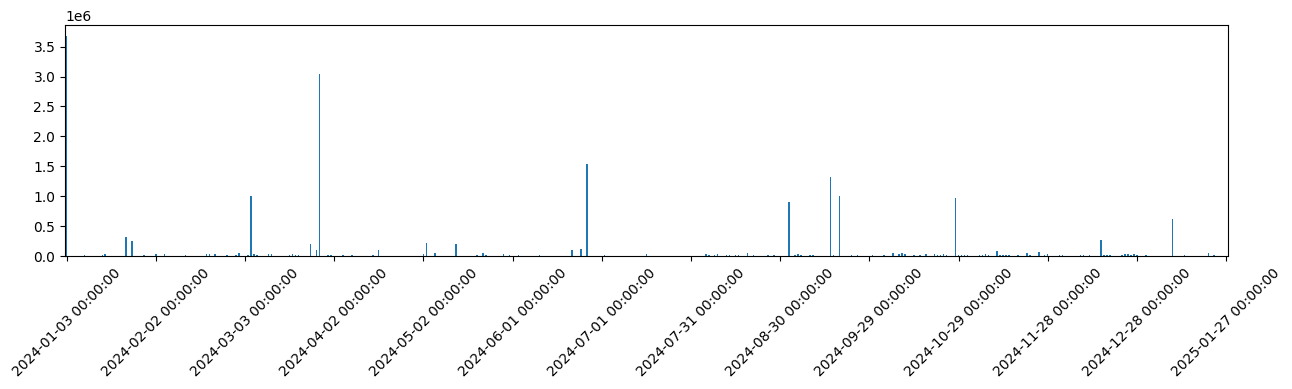

In [21]:
# посмотрим распределение сумм по дням
ax = data_fund['day_payments_sum'].plot(kind='bar',figsize=(15, 3))
ax.set_xticks(ax.get_xticks()[::30])  #настраиваем подписи на оси x
plt.xticks(rotation=45)
plt.show();

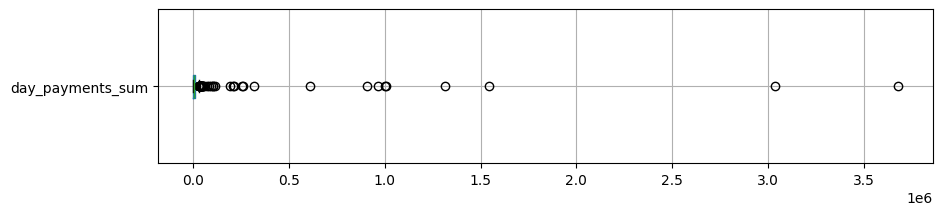

In [22]:
# и в виде boxplot
data_fund[['day_payments_sum']].boxplot(figsize=(10, 2), vert=False);

Далее заменим выбросы более 95%-перцентиля на медианное значение за весь период, и при обучении проверим метрики с заменой выбросов и без.

In [23]:
# заменяем агрегированные дневные суммы из THRESHOLD_CONST перцентиля на медианное значение
TRESHOLD_CONST = 0.90

threshold = data_fund['day_payments_sum'].quantile(TRESHOLD_CONST)
print(threshold)
median_full_sum = data_fund['day_payments_sum'].median()
print(median_full_sum)
data_fund.loc[data_fund['day_payments_sum'] > threshold, 'day_payments_sum'] = median_full_sum

30993.42
3375.76


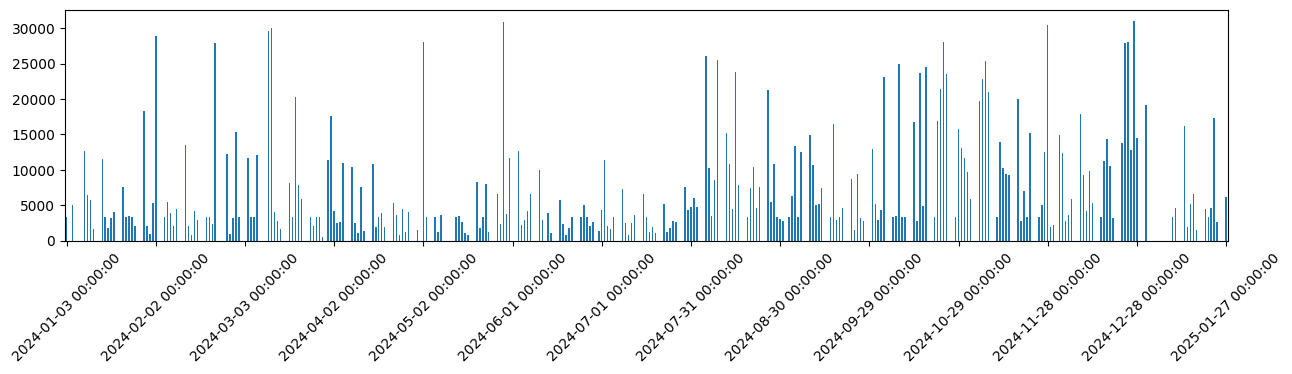

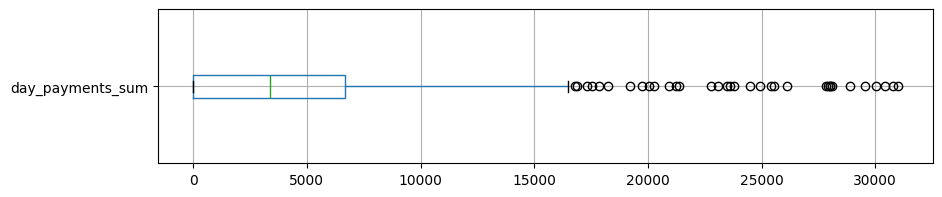

In [24]:
# посмотрим распределение сумм по дням
ax = data_fund['day_payments_sum'].plot(kind='bar',figsize=(15, 3))
ax.set_xticks(ax.get_xticks()[::30])  #настраиваем подписи на оси x
plt.xticks(rotation=45)
plt.show();

# и в виде boxplot
data_fund[['day_payments_sum']].boxplot(figsize=(10, 2), vert=False);

In [25]:
data_fund.isna().sum().sum()

0

In [26]:
# сдвигаем целевую переменную на 1 назад, чтобы модель училась предсказывать по текущему значению признаков будущий день
# актуально для всех моделей кроме SARIMAX
data_fund_shifted = data_fund.copy()
data_fund_shifted['target_shifted'] = data_fund_shifted['day_payments_sum'].shift(-1)

# убираем последнюю строку, так как она становится NaN из-за сдвига
data_fund_shifted = data_fund_shifted[:-1]

In [27]:
# определяем последние два месяца в данных для валидации и тестирования
test_month = data_fund_shifted.index.max().strftime('%Y-%m')  # последний год-месяц
val_month = (data_fund_shifted.index.max() - pd.DateOffset(months=1)).strftime('%Y-%m')  # предпоследний год-месяц

# разделяем данные
train_data_fund = data_fund_shifted.loc[data_fund_shifted.index < val_month]
val_data_fund = data_fund_shifted.loc[data_fund_shifted.index.strftime('%Y-%m') == val_month]
test_data_fund = data_fund_shifted.loc[data_fund_shifted.index.strftime('%Y-%m') == test_month]

# проверяем размеры и даты
display(train_data_fund.shape, val_data_fund.shape, test_data_fund.shape)

print("Последняя тренировочная дата:", train_data_fund.index.max().date())
print("Первая валидационная дата:", val_data_fund.index.min().date())
print("Последняя валидационная дата:", val_data_fund.index.max().date())
print("Первая тестовая дата:", test_data_fund.index.min().date())

(333, 58)

(31, 58)

(26, 58)

Последняя тренировочная дата: 2024-11-30
Первая валидационная дата: 2024-12-01
Последняя валидационная дата: 2024-12-31
Первая тестовая дата: 2025-01-01


In [28]:
# выделяем категоральные признаки
cat_features = ['day_of_week', 'week_number']

# формируем X_train и y_train
X_train = train_data_fund.drop(['day_payments_sum', 'target_shifted'], axis=1)
y_train = train_data_fund['target_shifted']

# формируем X_val и y_val
X_val = val_data_fund.drop(['day_payments_sum', 'target_shifted'], axis=1)
y_val = val_data_fund['target_shifted']

# формируем X_test и y_test
X_test = test_data_fund.drop(['day_payments_sum','target_shifted'], axis=1) 
y_test = test_data_fund['target_shifted']

## LSTM
### Подготовка данных
<a id='LSTM-подготовка-данных'></a> 
[К содержанию](#К-содержанию)

In [29]:
# масштабируем числовые признаки
scaler_x = StandardScaler()
X_train_num_scaled = scaler_x.fit_transform(X_train.drop(columns=cat_features))
X_val_num_scaled = scaler_x.transform(X_val.drop(columns=cat_features))
X_test_num_scaled = scaler_x.transform(X_test.drop(columns=cat_features))

# кодируем категориальные признаки
X_train_cat_encoded = pd.get_dummies(X_train[cat_features], dtype=float)
X_val_cat_encoded = pd.get_dummies(X_val[cat_features], dtype=float)
X_test_cat_encoded = pd.get_dummies(X_test[cat_features], dtype=float)

# Выравниваем столбцы (если в тестовой или валидационной выборке пропущены категории)
X_train_cat_encoded, X_val_cat_encoded = X_train_cat_encoded.align(X_val_cat_encoded, join='left', axis=1, fill_value=0)
X_train_cat_encoded, X_test_cat_encoded = X_train_cat_encoded.align(X_test_cat_encoded, join='left', axis=1, fill_value=0)
X_val_cat_encoded, X_test_cat_encoded = X_val_cat_encoded.align(X_test_cat_encoded, join='left', axis=1, fill_value=0)

# объединяем обратно
X_train_prepared = np.hstack([X_train_num_scaled, X_train_cat_encoded])
X_val_prepared = np.hstack([X_val_num_scaled, X_val_cat_encoded])
X_test_prepared = np.hstack([X_test_num_scaled, X_test_cat_encoded])

# масштабируем целевую переменную
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# преобразуем обратно в DataFrame для сохранения временных индексов
X_train_prepared = pd.DataFrame(
    X_train_prepared, 
    columns=list(X_train.drop(columns=cat_features).columns) + list(X_train_cat_encoded.columns),
    index=X_train.index)

X_val_prepared = pd.DataFrame(
    X_val_prepared,
    columns=list(X_val.drop(columns=cat_features).columns) + list(X_val_cat_encoded.columns),
    index=X_val.index)

X_test_prepared = pd.DataFrame(
    X_test_prepared, 
    columns=list(X_test.drop(columns=cat_features).columns) + list(X_test_cat_encoded.columns),
    index=X_test.index)

# преобразуем в Series(см.выше)
y_train_scaled = pd.Series(y_train_scaled.ravel(), name=y_train.name, index=y_train.index)
y_val_scaled = pd.Series(y_val_scaled.ravel(), name=y_val.name, index=y_val.index)
y_test_scaled = pd.Series(y_test_scaled.ravel(), name=y_test.name, index=y_test.index)

<a id='LSTM-построение-и-обучение-модели'></a> 
### Построение и обучение модели
[К содержанию](#К-содержанию)

In [30]:
# задаем шаги и количество разбиений временного ряда
time_steps = 7
n_splits = 7

# функция создания последовательностей для LSTM
def create_sequences(data, target, time_steps=1):
    X_seq, y_seq = [], []
    for i in range(len(data) - time_steps):
        X_seq.append(data[i:i + time_steps])
        y_seq.append(target[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

# создаем последовательности
X_seq, y_seq = create_sequences(X_train_prepared, y_train_scaled, time_steps)

# делим данные последовательно для временного ряда
tss = TimeSeriesSplit(n_splits=n_splits)
rmse_scores_train = []
rmse_scores_test = []
smape_scores_train = []
smape_scores_test = []
mase_scores_train = []
mase_scores_test = []



for train_idx, test_idx in tss.split(X_seq):
    X_train_s, X_test_s = X_seq[train_idx], X_seq[test_idx]
    y_train_s, y_test_s = y_seq[train_idx], y_seq[test_idx]

    # конвертируем данные в тензоры для pytorch
    X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_s, dtype=torch.float32).view(-1, 1)
    X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_s, dtype=torch.float32).view(-1, 1)

    # фомируем модель LSTM
    class LSTMModel(nn.Module):
        def __init__(self, input_size, hidden_size, output_size):
            super(LSTMModel, self).__init__()
            self.lstm1 = nn.LSTM(input_size, hidden_size, batch_first=True)
            #self.dropout1 = nn.Dropout(0.1)
            #self.lstm2 = nn.LSTM(hidden_size, hidden_size, batch_first=True)
            #self.dropout2 = nn.Dropout(0.2)
            self.fc1 = nn.Linear(hidden_size, 256)
            self.fc2 = nn.Linear(256, output_size)

        def forward(self, x):
            x, _ = self.lstm1(x)
            #x = self.dropout1(x)
            #x, _ = self.lstm2(x)
            #x = self.dropout2(x)
            x = x[:, -1, :]
            x = self.fc1(x)
            x = torch.relu(x)
            x = self.fc2(x)
            return x

        
    # инициализация модели
    input_size = X_train_s.shape[2]
    hidden_size = 256
    output_size = 1
    model_lstm = LSTMModel(input_size, hidden_size, output_size)

    # задаем функцию потерь и оптимизатор
    #criterion = nn.MSELoss()
    criterion = nn.HuberLoss(delta=1.5)
    optimizer = optim.AdamW(model_lstm.parameters(), lr=0.001, weight_decay=1e-4)

    # создаем ReduceLROnPlateau
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

    # обучение модели
    num_epochs = 200
    for epoch in range(num_epochs):
        model_lstm.train()
        optimizer.zero_grad()
        output = model_lstm(X_train_tensor)
        loss = criterion(output, y_train_tensor)
        loss.backward()
        optimizer.step()

        # вычисление RMSE, SMAPE и MASE на тренировочных данных
        if (epoch + 1) % 10 == 0:
            # разворачиваем масштабированные значения
            y_train_original = scaler_y.inverse_transform(y_train_tensor.detach().numpy().reshape(-1, 1))
            y_train_pred_original = scaler_y.inverse_transform(output.detach().numpy().reshape(-1, 1))

            # вычисление RMSE, SMAPE и MASE на развернутых данных
            train_rmse = np.sqrt(mean_squared_error(y_train_original, y_train_pred_original))
            train_smape = smape(y_train_original, y_train_pred_original)
            train_mase = mase(y_train_original, y_train_pred_original, y_train_original)
            #print(f"Эпоха [{epoch + 1}/{num_epochs}], Потеря: {loss.item():.4f}, RMSE (train): {train_rmse:.4f}, SMAPE (train): {train_smape:.4f}")
    
    # Вызываем ReduceLROnPlateau
    scheduler.step(loss)  # передаем loss для отслеживания

    # вычисление RMSE,SMAPE и MASE на тестовых данных после обучения
    model_lstm.eval()
    with torch.no_grad():
        y_pred = model_lstm(X_test_tensor)
        
        # разворачиваем масштабированные прогнозы
        y_test_original = scaler_y.inverse_transform(y_test_tensor.numpy().reshape(-1, 1))
        y_pred_original = scaler_y.inverse_transform(y_pred.numpy().reshape(-1, 1))

        # вычисление RMSE,SMAPE и MASE на развернутых данных
        test_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
        test_smape = smape(y_test_original, y_pred_original)
        test_mase = mase(y_test_original, y_pred_original, y_train_original)
        #print(f"RMSE на тестовых данных: {test_rmse:.4f}, SMAPE на тестовых данных: {test_smape:.4f}  \n")

    rmse_scores_train.append(train_rmse)
    rmse_scores_test.append(test_rmse)
    smape_scores_train.append(train_smape)
    smape_scores_test.append(test_smape)
    mase_scores_train.append(train_mase)
    mase_scores_test.append(test_mase)



# выводим средние метрики RMSE, SMAPE и MASE для всех фолдов
print(
    f"Средний RMSE на тренировочных данных: {np.mean(rmse_scores_train):.4f}, "
    f"Средний SMAPE на тренировочных данных: {np.mean(smape_scores_train):.4f}, "
    f"Средний MASE на тренировочных данных: {np.mean(mase_scores_train):.4f}"
)
print(
    f"Средний RMSE на тестовых данных: {np.mean(rmse_scores_test):.4f}, "
    f"Средний SMAPE на тестовых данных: {np.mean(smape_scores_test):.4f}, "
    f"Средний MASE на тестовых данных: {np.mean(mase_scores_test):.4f}"
)

/var/folders/yf/tnhxwgts2035718d0nhj30rw0000gn/T/ipykernel_45499/1238802703.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_seq.append(target[i + time_steps])


Средний RMSE на тренировочных данных: 117.2588, Средний SMAPE на тренировочных данных: 63.1200, Средний MASE на тренировочных данных: 0.0134
Средний RMSE на тестовых данных: 7771.0468, Средний SMAPE на тестовых данных: 112.9172, Средний MASE на тестовых данных: 0.9044


<a id='LSTM-валидация-модели-с-визуализацией-прогноза'></a> 
### Валидация модели с визуализацией прогноза
[К содержанию](#К-содержанию)

In [31]:
# формируем последовательности
X_seq_full, y_seq_full = create_sequences(X_train_prepared, y_train_scaled, time_steps)

# преобразуем в тензоры
X_full_tensor = torch.tensor(X_seq_full, dtype=torch.float32)
y_full_tensor = torch.tensor(y_seq_full, dtype=torch.float32).view(-1, 1)

# обучаем модель на всем тренировочном датасете
for epoch in range(num_epochs):
    model_lstm.train()
    optimizer.zero_grad()
    output = model_lstm(X_full_tensor)
    loss = criterion(output, y_full_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        y_full_original = scaler_y.inverse_transform(y_full_tensor.detach().numpy().reshape(-1, 1))
        y_full_pred_original = scaler_y.inverse_transform(output.detach().numpy().reshape(-1, 1))
        full_rmse = np.sqrt(mean_squared_error(y_full_original, y_full_pred_original))
        full_smape = smape(y_full_original, y_full_pred_original)
        full_mase = mase(y_full_original, y_full_pred_original,y_full_original)
        print(f"Эпоха [{epoch + 1}/{num_epochs}], Потеря: {loss.item():.4f}, RMSE: {full_rmse:.4f}, SMAPE: {full_smape:.4f},MASE: {full_mase:.4f}")

/var/folders/yf/tnhxwgts2035718d0nhj30rw0000gn/T/ipykernel_45499/1238802703.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_seq.append(target[i + time_steps])


Эпоха [10/200], Потеря: 0.0372, RMSE: 1892.2742, SMAPE: 81.5931,MASE: 0.2197
Эпоха [20/200], Потеря: 0.0119, RMSE: 1066.0021, SMAPE: 73.7020,MASE: 0.1257
Эпоха [30/200], Потеря: 0.0050, RMSE: 688.5644, SMAPE: 68.9308,MASE: 0.0845
Эпоха [40/200], Потеря: 0.0025, RMSE: 488.9313, SMAPE: 66.1306,MASE: 0.0535
Эпоха [50/200], Потеря: 0.0015, RMSE: 373.1407, SMAPE: 63.8437,MASE: 0.0377
Эпоха [60/200], Потеря: 0.0009, RMSE: 299.7462, SMAPE: 62.7078,MASE: 0.0298
Эпоха [70/200], Потеря: 0.0006, RMSE: 242.3621, SMAPE: 61.8075,MASE: 0.0227
Эпоха [80/200], Потеря: 0.0004, RMSE: 194.7109, SMAPE: 61.0992,MASE: 0.0174
Эпоха [90/200], Потеря: 0.0003, RMSE: 158.5398, SMAPE: 60.6317,MASE: 0.0139
Эпоха [100/200], Потеря: 0.0002, RMSE: 131.7334, SMAPE: 60.2846,MASE: 0.0112
Эпоха [110/200], Потеря: 0.0001, RMSE: 111.6375, SMAPE: 60.0186,MASE: 0.0090
Эпоха [120/200], Потеря: 0.0001, RMSE: 96.9628, SMAPE: 59.8450,MASE: 0.0075
Эпоха [130/200], Потеря: 0.0001, RMSE: 85.6315, SMAPE: 59.7016,MASE: 0.0064
Эпоха [1

In [32]:
# добавляем последние time_steps строк из тренировочного набора в валидационный набор
# (тк они нужны для запуска первого прогноза, чтобы не тратить на это валидационные данные)
X_val_full = pd.concat([X_train_prepared.tail(time_steps), X_val_prepared], axis=0)
y_val_full = pd.concat([y_train_scaled.tail(time_steps), y_val_scaled], axis=0)

# создаем последовательности для тестового набора
X_seq_val, y_seq_val = create_sequences(X_val_full.values, y_val_full.values, time_steps)

# преобразуем в тензоры
X_val_tensor = torch.tensor(X_seq_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_seq_val, dtype=torch.float32).view(-1, 1)

# делаем прогноз
model_lstm.eval()
with torch.no_grad():
    y_pred = model_lstm(X_val_tensor)

# разворачиваем масштабированные данные
y_val_original = np.round(scaler_y.inverse_transform(y_val_tensor.numpy()).flatten(), decimals=2)
y_val_pred_lstm = np.round(scaler_y.inverse_transform(y_pred.numpy()).flatten(), decimals=2)

# преобразуем y_val_original в Series с правильными временныеми индексами
y_val_original = pd.Series(y_val_original, index=y_val_full.index[-len(y_val_original):])

# считаем метрики
rmse_val_lstm = np.sqrt(mean_squared_error(y_val_original, y_val_pred_lstm))
smape_val_lstm = smape(y_val_original, y_val_pred_lstm)
mase_val_lstm = mase(y_val_original, y_val_pred_lstm,y_train_original)

print(f'Метрика RMSE на валидационных данных: {rmse_val_lstm:.3f}')
print(f'Метрика SMAPE на валидационных данных: {smape_val_lstm:.4f}')
print(f'Метрика MASE на валидационных данных: {mase_val_lstm:.4f}')

Метрика RMSE на валидационных данных: 7705.621
Метрика SMAPE на валидационных данных: 107.6432
Метрика MASE на валидационных данных: 0.9435


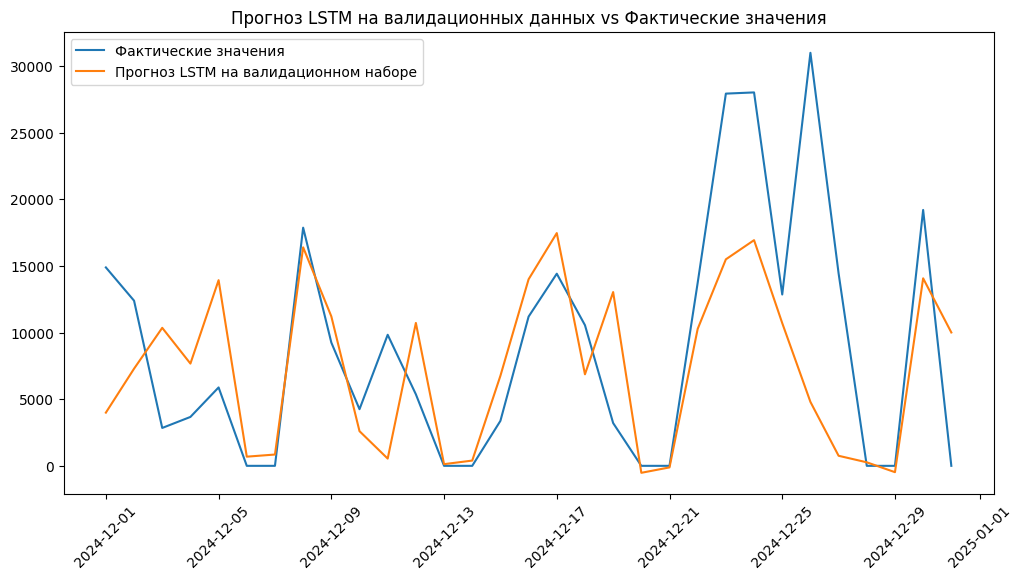

In [33]:
# смотрим на графике 
plt.figure(figsize=(12, 6))
plt.plot(y_val_original.index, y_val_original.values, label='Фактические значения')
plt.plot(y_val_original.index, y_val_pred_lstm, label='Прогноз LSTM на валидационном наборе')
plt.xticks(rotation=45)
plt.title('Прогноз LSTM на валидационных данных vs Фактические значения')
plt.legend()
plt.show()


In [34]:
y_val_original.describe()

count      31.00
mean     8909.71
std      9023.90
min        -0.00
25%        -0.00
50%      5883.35
75%     14079.41
max     30993.42
dtype: float64

## SARIMAX
### Подготовка данных
<a id='SARIMAX-подготовка-данных'></a> 
[К содержанию](#К-содержанию)

In [35]:
# загружаем ряд с несдвинутым целевым признаком и разбиваем на тренировочную, валидационную и тестовую выборки
y_train_sarimax = data_fund.loc[data_fund.index < val_month, 'day_payments_sum'].copy()#.asfreq('D')
y_val_sarimax = data_fund.loc[data_fund.index.strftime('%Y-%m') == val_month, 'day_payments_sum'].copy()#.asfreq('D')
y_test_sarimax = data_fund.loc[data_fund.index.strftime('%Y-%m') == test_month, 'day_payments_sum'].copy()#.asfreq('D')


display(y_train_sarimax.shape,
        y_val_sarimax.shape,
        y_test_sarimax.shape)

print("Первая тренировочная дата:", y_train_sarimax.index.min().date())
print("Последняя тренировочная дата:", y_train_sarimax.index.max().date())
print("Первая валидационная дата:", y_val_sarimax.index.min().date())
print("Последняя валидационная дата:", y_val_sarimax.index.max().date())
print("Первая тестовая дата:", y_test_sarimax.index.min().date())

(333,)

(31,)

(27,)

Первая тренировочная дата: 2024-01-03
Последняя тренировочная дата: 2024-11-30
Первая валидационная дата: 2024-12-01
Последняя валидационная дата: 2024-12-31
Первая тестовая дата: 2025-01-01


In [36]:
y_train_sarimax.head()

2024-01-03   3375.76
2024-01-04      0.00
2024-01-05   5085.37
2024-01-06      0.00
2024-01-07      0.00
Name: day_payments_sum, dtype: float64

<a id='SARIMAX-построение-и-обучение-модели'></a> 
### Построение и обучение модели
[К содержанию](#К-содержанию)

In [37]:
# функция кросс-валидаци для подбора гиперпараметров SARIMAX
def cross_validate_sarima(data, order, seasonal_order, n_splits=n_splits):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rmse_scores = []
    smape_scores = []
    mase_scores = []
    best_model = None
    best_rmse = np.inf
    
    data = data.asfreq('D')
    
    for train_index, test_index in tscv.split(data):
        train = data.iloc[train_index]
        test = data.iloc[test_index]
        
        model_sarimax = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        results = model_sarimax.fit(disp=False, 
                            maxiter=1000,
                            optim_score='harvey',
                            method='powell',
                            cov_type='robust')
        
        # делаем прогноз
        forecast = results.get_forecast(steps=len(test))
        predicted_mean = forecast.predicted_mean
        predicted_mean = predicted_mean.clip(lower=0) #отрицательные меняем на ноль

        # cчитаем RMSE
        current_rmse = np.sqrt(mean_squared_error(test, predicted_mean))
        rmse_scores.append(current_rmse)
        
        # cчитаем SMAPE
        current_smape = smape(test, predicted_mean)
        smape_scores.append(current_smape)

        # cчитаем MASE
        current_mase = mase(test, predicted_mean, train)
        mase_scores.append(current_mase)
        
        # сохраняем лучший вариант метрики и модели
        if current_rmse < best_rmse:
            best_rmse = current_rmse
            #best_smape = current_smape
            best_model = results
    
    # возвращаем средние значения RMSE,SMAPE и MASE
    return np.nanmean(rmse_scores), np.nanmean(smape_scores),np.nanmean(mase_scores), best_model

# задаем наборы гиперпараметров для SARIMAX
param_sets = [
    
    ((1, 1, 0), (0, 1, 1, 7)),  # упрощенная модель
    ((0, 1, 1), (0, 1, 1, 7)),  # базовый вариант
    ((1, 0, 0), (1, 1, 0, 7)),  # AR-структура
    ((0, 1, 2), (0, 1, 1, 7)),  # с увеличенным MA
    ((0, 1, 1), (1, 1, 1, 7)),  # с сезонным AR
    ((1, 1, 7), (0, 0, 0, 0)),  # ручной вариант
    ((1, 1, 2), (0, 0, 0, 0))   # ручной вариант 2
]

# перебор параметров
best_model_overall_sarimax = None
best_rmse_overall_sarimax = np.inf
best_smape_overall_sarimax = np.inf
best_mase_overall_sarimax = np.inf

for param in param_sets:
    
    average_rmse_sarimax, average_smape_sarimax,average_mase_sarimax, best_model_sarimax = cross_validate_sarima(
        y_train_sarimax,
        param[0],
        param[1]
    )
    print(f"Средние значения метрик для набора параметров {param}: "
          f"RMSE - {average_rmse_sarimax:.2f} SMAPE: {average_smape_sarimax:.2f} MASE: {average_mase_sarimax:.2f}")

    if average_rmse_sarimax < best_rmse_overall_sarimax:
        best_rmse_overall_sarimax = average_rmse_sarimax
        best_model_overall_sarimax = best_model_sarimax
        best_smape_overall_sarimax = average_smape_sarimax
        best_mase_overall_sarimax = average_mase_sarimax
    

Средние значения метрик для набора параметров ((1, 1, 0), (0, 1, 1, 7)): RMSE - 6556.30 SMAPE: 118.52 MASE: 0.80
Средние значения метрик для набора параметров ((0, 1, 1), (0, 1, 1, 7)): RMSE - 6204.16 SMAPE: 101.72 MASE: 0.81
Средние значения метрик для набора параметров ((1, 0, 0), (1, 1, 0, 7)): RMSE - 6469.29 SMAPE: 99.29 MASE: 0.76
Средние значения метрик для набора параметров ((0, 1, 2), (0, 1, 1, 7)): RMSE - 6191.53 SMAPE: 103.57 MASE: 0.81
Средние значения метрик для набора параметров ((0, 1, 1), (1, 1, 1, 7)): RMSE - 6192.13 SMAPE: 102.39 MASE: 0.81
Средние значения метрик для набора параметров ((1, 1, 7), (0, 0, 0, 0)): RMSE - 6764.32 SMAPE: 107.10 MASE: 0.94
Средние значения метрик для набора параметров ((1, 1, 2), (0, 0, 0, 0)): RMSE - 6764.49 SMAPE: 105.27 MASE: 0.91


In [38]:
# переобучаем лучшую модель на всем датасете инкрементально, чтобы использовать потом валидационные и тестовые прогнозы

# забираем всю последовательность для обучения и прогноза 
y_full_sarimax = data_fund.loc[:, 'day_payments_sum'].copy().asfreq('D')

# создаем пустую серию для хранения прогнозов
sarima_forecast = pd.Series(index=y_full_sarimax.index, dtype=float)

# определяем минимальный размер выборки для начала обучения SARIMAX
min_full_size = 30

# заполняем начальные значения средними про предыдущим значениям
sarima_forecast.iloc[0] = y_full_sarimax.iloc[0]  # первое значение как есть
 
for i in range(1, min_full_size):
    sarima_forecast.iloc[i] = y_full_sarimax.iloc[:i].mean()

# задаем параметры модели
order = best_model_overall_sarimax.model.order
seasonal_order = best_model_overall_sarimax.model.seasonal_order

# запускаем обучение и прогнозирование, начиная с min_full_size
for i in range(min_full_size, len(y_full_sarimax)):
    # используем все доступные данные для обучения
    train_series = y_full_sarimax.iloc[:i].asfreq('D')
    
    model_sarimax_full = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False,
          maxiter=1000,
          optim_score='harvey',
          method='powell',
          cov_type='robust')
    
    # прогнозируем следующее значение и заменяем отрицательные значения на 0
    forecast = model_sarimax_full.get_forecast(steps=1)
    predicted_value = forecast.predicted_mean.item()  # достаем предсказанное значение
    predicted_value = max(predicted_value, 0)

    sarima_forecast.iloc[i] = predicted_value

# обнуляем первые значения, чтобы они не влияли на CatBoost
sarima_forecast.iloc[:min_full_size] = np.nan

print(f'Лучшая модель с RMSE {best_rmse_overall_sarimax:.2f} и параметрами {order, seasonal_order} обучена на всех данных')
print("Первые 15 прогнозов:")
display(sarima_forecast.head(15))

Лучшая модель с RMSE 6191.53 и параметрами ((0, 1, 2), (0, 1, 1, 7)) обучена на всех данных
Первые 15 прогнозов:


2024-01-03   NaN
2024-01-04   NaN
2024-01-05   NaN
2024-01-06   NaN
2024-01-07   NaN
2024-01-08   NaN
2024-01-09   NaN
2024-01-10   NaN
2024-01-11   NaN
2024-01-12   NaN
2024-01-13   NaN
2024-01-14   NaN
2024-01-15   NaN
2024-01-16   NaN
2024-01-17   NaN
Freq: D, dtype: float64

<a id='SARIMAX-валидация-модели-с-визуализацией-прогноза'></a> 
### Валидация модели с визуализацией прогноза
[К содержанию](#К-содержанию)

In [39]:
display(y_val_sarimax.head(1))
y_val_sarimax.tail(1)

2024-12-01   0.00
Name: day_payments_sum, dtype: float64

2024-12-31   19201.81
Name: day_payments_sum, dtype: float64

In [40]:
# отбираем прогнозы и реальные значения для валидации со сдвигом на 1 значение назад, для корректоного сравнения с другими моделями
y_val_sarimax = data_fund.shift(-1).loc[data_fund.index.strftime('%Y-%m') == val_month, 'day_payments_sum'].copy().asfreq('D')
y_val_pred_sarimax = sarima_forecast.shift(-1).loc[sarima_forecast.index.strftime('%Y-%m') == val_month].copy().asfreq('D')

display(y_val_pred_sarimax.head(1),
        y_val_pred_sarimax.tail(1))

y_val_pred_sarimax.describe()

2024-12-01   9624.42
Freq: D, dtype: float64

2024-12-31   14812.79
Freq: D, dtype: float64

count      31.00
mean     8579.00
std      4377.48
min       180.09
25%      6541.94
50%     10073.95
75%     11478.18
max     14812.79
dtype: float64

Метрика RMSE на валидационных данных: 8194.27
Метрика SMAPE на валидационных данных: 100.94
Метрика MASE на валидационных данных: 1.04


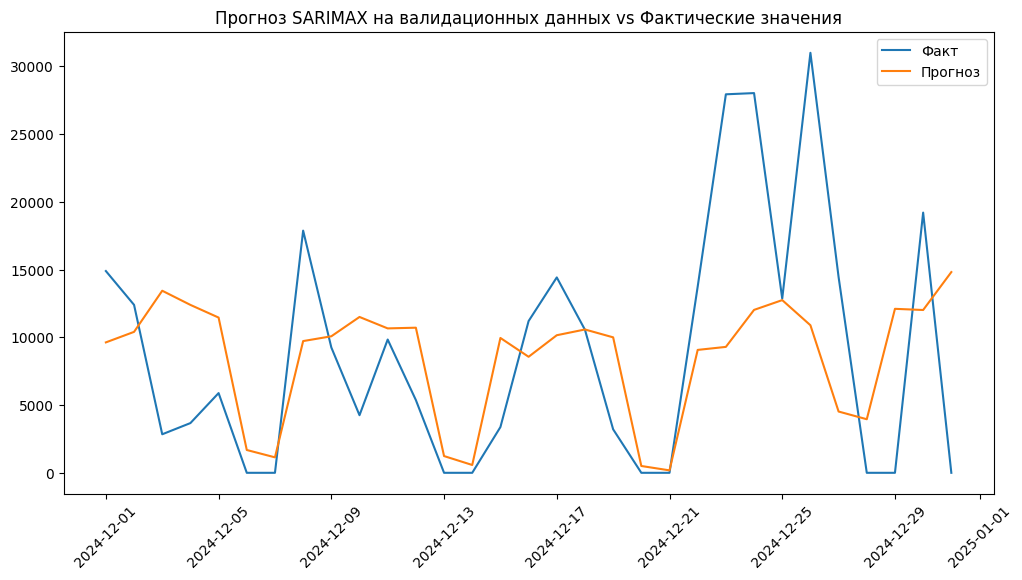

In [41]:
# считаем метрики RMSE,SMAPE и MASE
rmse_val_sarimax = np.sqrt(mean_squared_error(y_val_sarimax, y_val_pred_sarimax))
smape_val_sarimax = smape(y_val_sarimax, y_val_pred_sarimax)
mase_val_sarimax = mase(y_val_sarimax, y_val_pred_sarimax, y_train_sarimax)


print(f"Метрика RMSE на валидационных данных: {rmse_val_sarimax:.2f}")
print(f"Метрика SMAPE на валидационных данных: {smape_val_sarimax:.2f}")
print(f"Метрика MASE на валидационных данных: {mase_val_sarimax:.2f}")


# строим график прогноза
plt.figure(figsize=(12, 6))
plt.plot(y_val_sarimax, label='Факт')
plt.plot(y_val_pred_sarimax, label='Прогноз')
plt.title('Прогноз SARIMAX на валидационных данных vs Фактические значения')
plt.xticks(rotation=45)
plt.legend()
plt.show()

<a id='Catboost-подготовка-данных'></a> 
## Catboost (+sarimax)
### Подготовка данных
[К содержанию](#К-содержанию)


In [42]:
# добавляем прогноз sarimax как признак в датасет + сдвигаем его на 1 назад, чтобы соответствовать временным точкам прочих признаков 

X_train['sarima_forecast'] = sarima_forecast.shift(-1).reindex(X_train.index)
#X_train = X_train.dropna()
X_train.head(5)

,day_account_id_nunique,day_contractor_id_nunique,day_article_id_nunique,day_project_id_nunique,day_counterpartie_id_nunique,day_donor_id_nunique,day_donor_cat_id_nunique,day_articles__parent_id_nunique,day_projects__parent_id_nunique,day_counterparties__parent_id_nunique,day_robots__id_nunique,day_payments_count,day_min_payment,day_max_payment,day_purpose_mean,day_purpose_pca_1,day_purpose_pca_2,day_purpose_pca_3,day_purpose_pca_4,day_purpose_pca_5,account_id_ufreq_mean,contractor_id_ufreq_mean,article_id_ufreq_mean,project_id_ufreq_mean,counterpartie_id_ufreq_mean,donor_id_ufreq_mean,donor_cat_id_ufreq_mean,articles__parent_id_ufreq_mean,projects__parent_id_ufreq_mean,counterparties__parent_id_ufreq_mean,robots__id_ufreq_mean,account_id_ufreq_std,contractor_id_ufreq_std,article_id_ufreq_std,project_id_ufreq_std,counterpartie_id_ufreq_std,donor_id_ufreq_std,donor_cat_id_ufreq_std,articles__parent_id_ufreq_std,projects__parent_id_ufreq_std,counterparties__parent_id_ufreq_std,robots__id_ufreq_std,day_of_week,day_of_week_sin,day_of_week_cos,week_number,week_number_sin,week_number_cos,rolling_day_payments,day_payments_sum_lag_1,day_payments_sum_lag_2,day_payments_sum_lag_3,day_payments_sum_lag_4,day_payments_sum_lag_5,day_payments_sum_lag_6,day_payments_sum_lag_7,sarima_forecast
2024-01-03,1.00,9.00,3.00,2.00,1.00,1.00,2.00,2.00,1.00,2.00,3.00,137.00,0.01,3671794.35,0.00,2.63,1.97,-0.53,0.04,0.06,1.00,0.91,0.92,0.96,1.00,1.00,0.96,0.96,1.00,0.99,0.92,0.00,0.23,0.16,0.08,0.00,0.00,0.08,0.08,0.00,0.09,0.16,2,0.97,-0.22,1,0.95,0.31,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2024-01-04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3,0.43,-0.90,1,0.95,0.31,3677931.12,3677931.12,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2024-01-05,1.00,12.00,3.00,2.00,1.00,1.00,2.00,2.00,1.00,1.00,3.00,283.00,0.01,2000.00,0.00,2.78,2.14,-0.56,0.04,0.05,1.00,0.93,0.94,0.96,1.00,1.00,0.96,0.96,1.00,1.00,0.94,0.00,0.19,0.10,0.08,0.00,0.00,0.08,0.08,0.00,0.00,0.10,4,-0.43,-0.90,1,0.95,0.31,1838965.56,0.00,3677931.12,0.00,0.00,0.00,0.00,0.00,NaN
2024-01-06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5,-0.97,-0.22,1,0.95,0.31,1227672.16,5085.37,0.00,3677931.12,0.00,0.00,0.00,0.00,NaN
2024-01-07,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6,-0.78,0.62,1,0.95,0.31,920754.12,0.00,5085.37,0.00,3677931.12,0.00,0.00,0.00,NaN


<a id='Catboost-построение-и-обучение-модели'></a> 
### Построение и обучение модели
[К содержанию](#К-содержанию)

In [43]:
# подготовим обучение
cat_features = ['day_of_week', 'week_number']

tss = TimeSeriesSplit(n_splits = n_splits)

# итоговый пайплайн
pipe_final = Pipeline([
    ('model', CatBoostRegressor(
        silent=True,
        random_state=RANDOM_STATE,
        cat_features=cat_features))
])

# сетка гиперпараметров
param_grid = [
    # CatBoostRegressor
    {
        'model__iterations': [100,200,500],
        'model__depth': [2,5,7],
        'model__learning_rate': [0.1,0.001],
        'model__l2_leaf_reg': [2],
        #'model__subsample': [0.8],
        'model__loss_function': ['RMSE'], # 'MAE', 'Quantile:alpha=0.8'],
        'model__max_bin': [256],
        'model__random_strength': [1],
        'model__early_stopping_rounds':[10]
        
    }
]

In [44]:
# полный перебор гиперпараметров с помощью GridSearchCV
grid_search = GridSearchCV(
    pipe_final,
    param_grid=param_grid,
    cv=tss,
    scoring={'neg_mean_squared_error': 'neg_mean_squared_error', 'smape': smape_scorer},
    refit='neg_mean_squared_error',
    n_jobs=-1,
    error_score='raise'
)

# обучение модели
model = grid_search.fit(X_train, y_train)

# выгружаем метрики
best_score_neg_mse = grid_search.best_score_
best_score_rmse = round(np.sqrt(-best_score_neg_mse), 3)
best_score_smape = round(-grid_search.cv_results_['mean_test_smape'][grid_search.best_index_], 3)

# считаем MASE
y_pred_train = model.predict(X_train)
best_score_mase = mase(y_train, y_pred_train, y_train)

# выводим результаты
print(f'Метрика RMSE лучшей модели на тренировочной выборке при кросс-валидации: {best_score_rmse}')
print(f'Метрика SMAPE лучшей модели на тренировочной выборке при кросс-валидации: {best_score_smape}')
print(f'Метрика MASE лучшей модели на тренировочной выборке: {round(best_score_mase, 3)}')
print(f'Параметры лучшей модели: {grid_search.best_params_}')

Метрика RMSE лучшей модели на тренировочной выборке при кросс-валидации: 6224.544
Метрика SMAPE лучшей модели на тренировочной выборке при кросс-валидации: 101.753
Метрика MASE лучшей модели на тренировочной выборке: 0.182
Параметры лучшей модели: {'model__depth': 7, 'model__early_stopping_rounds': 10, 'model__iterations': 200, 'model__l2_leaf_reg': 2, 'model__learning_rate': 0.1, 'model__loss_function': 'RMSE', 'model__max_bin': 256, 'model__random_strength': 1}


In [45]:
# берем модель CatBoostRegressor из пайплайна
catboost_model = model.best_estimator_.named_steps["model"]

# получаем важность признаков
feature_importances = catboost_model.get_feature_importance()
feature_names = catboost_model.feature_names_

# преобразовываем в DataFrame, сортируем и выводим
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

                                  Feature  Importance
54                 day_payments_sum_lag_6       16.43
42                            day_of_week        9.21
56                        sarima_forecast        5.82
48                   rolling_day_payments        4.50
53                 day_payments_sum_lag_5        3.98
15                      day_purpose_pca_1        3.74
18                      day_purpose_pca_4        3.13
1               day_contractor_id_nunique        3.05
22                  article_id_ufreq_mean        3.04
50                 day_payments_sum_lag_2        2.93
51                 day_payments_sum_lag_3        2.93
49                 day_payments_sum_lag_1        2.76
32                contractor_id_ufreq_std        2.55
46                        week_number_sin        2.49
45                            week_number        2.44
13                        day_max_payment        2.16
52                 day_payments_sum_lag_4        1.96
21               contractor_

<a id='Catboost-валидация-модели-с-визуализацией-прогноза'></a> 
### Валидация модели с визуализацией прогноза
[К содержанию](#К-содержанию)

In [46]:
# добавляем прогнозы sarimax в валидационный датафрейм
X_val['sarima_forecast'] = sarima_forecast.shift(-1).reindex(X_val.index)
X_val.head(5)

,day_account_id_nunique,day_contractor_id_nunique,day_article_id_nunique,day_project_id_nunique,day_counterpartie_id_nunique,day_donor_id_nunique,day_donor_cat_id_nunique,day_articles__parent_id_nunique,day_projects__parent_id_nunique,day_counterparties__parent_id_nunique,day_robots__id_nunique,day_payments_count,day_min_payment,day_max_payment,day_purpose_mean,day_purpose_pca_1,day_purpose_pca_2,day_purpose_pca_3,day_purpose_pca_4,day_purpose_pca_5,account_id_ufreq_mean,contractor_id_ufreq_mean,article_id_ufreq_mean,project_id_ufreq_mean,counterpartie_id_ufreq_mean,donor_id_ufreq_mean,donor_cat_id_ufreq_mean,articles__parent_id_ufreq_mean,projects__parent_id_ufreq_mean,counterparties__parent_id_ufreq_mean,robots__id_ufreq_mean,account_id_ufreq_std,contractor_id_ufreq_std,article_id_ufreq_std,project_id_ufreq_std,counterpartie_id_ufreq_std,donor_id_ufreq_std,donor_cat_id_ufreq_std,articles__parent_id_ufreq_std,projects__parent_id_ufreq_std,counterparties__parent_id_ufreq_std,robots__id_ufreq_std,day_of_week,day_of_week_sin,day_of_week_cos,week_number,week_number_sin,week_number_cos,rolling_day_payments,day_payments_sum_lag_1,day_payments_sum_lag_2,day_payments_sum_lag_3,day_payments_sum_lag_4,day_payments_sum_lag_5,day_payments_sum_lag_6,day_payments_sum_lag_7,sarima_forecast
2024-12-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6,-0.78,0.62,1,0.95,0.31,18079.28,2215.29,2031.09,30447.49,12588.66,5034.01,74238.42,0.00,9624.42
2024-12-02,1.00,23.00,5.00,2.00,1.00,1.00,3.00,2.00,1.00,2.00,5.00,362.00,0.01,5520.00,0.00,2.60,1.96,-0.60,-0.01,0.06,1.00,0.91,0.93,0.96,1.00,1.00,0.96,0.96,1.00,1.00,0.93,0.00,0.23,0.15,0.05,0.00,0.00,0.07,0.05,0.00,0.05,0.15,0,0.00,1.00,1,0.95,0.31,18079.28,0.00,2215.29,2031.09,30447.49,12588.66,5034.01,74238.42,10400.47
2024-12-03,1.00,11.00,3.00,2.00,1.00,1.00,2.00,2.00,1.00,1.00,3.00,364.00,0.01,5000.00,0.00,2.78,2.10,-0.59,0.00,0.08,1.00,0.94,0.94,0.96,1.00,1.00,0.96,0.96,1.00,1.00,0.94,0.00,0.16,0.08,0.05,0.00,0.00,0.05,0.05,0.00,0.00,0.08,1,0.78,0.62,1,0.95,0.31,9600.80,14889.03,0.00,2215.29,2031.09,30447.49,12588.66,5034.01,13435.61
2024-12-04,1.00,6.00,3.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,3.00,282.00,0.01,980.00,0.00,3.04,2.15,-0.62,-0.02,0.09,1.00,0.95,0.94,0.96,1.00,1.00,0.96,0.96,1.00,1.00,0.94,0.00,0.13,0.11,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.11,2,0.97,-0.22,1,0.95,0.31,10652.07,12392.94,14889.03,0.00,2215.29,2031.09,30447.49,12588.66,12390.77
2024-12-05,1.00,7.00,4.00,1.00,1.00,1.00,2.00,1.00,1.00,2.00,4.00,272.00,0.01,1000.00,0.00,2.99,2.14,-0.59,-0.02,0.08,1.00,0.94,0.94,0.96,1.00,1.00,0.96,0.96,1.00,1.00,0.94,0.00,0.14,0.11,0.00,0.00,0.00,0.06,0.00,0.00,0.06,0.11,3,0.43,-0.90,1,0.95,0.31,9259.88,2843.33,12392.94,14889.03,0.00,2215.29,2031.09,30447.49,11455.54


Метрика RMSE  на валидационном наборе: 8021.44
Метрика SMAPE на валидационном наборе: 105.91
Метрика MASE на валидационном наборе: 1.01


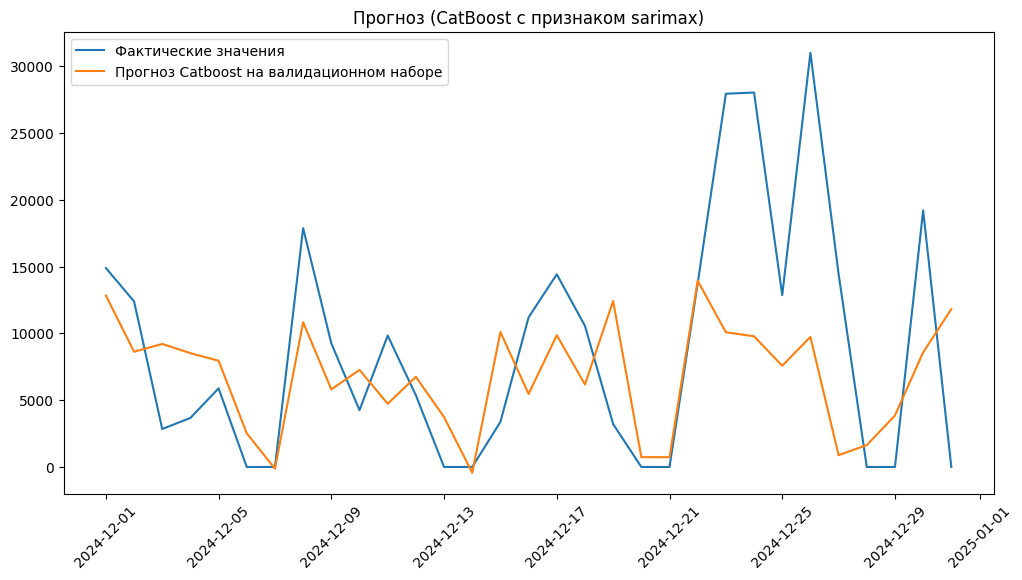

In [47]:
# тестирование catboost на валидационной выборке

# переобучаем лучшую модель на всем тренировочном наборе
final_model_cb = grid_search.best_estimator_
final_model_cb.fit(X_train, y_train)

# делаем прогноз и считаем метрики RMSE и SMAPE на валидационном наборе
y_val_pred_cb = np.round(final_model_cb.predict(X_val), decimals=2)

rmse_val_cb = np.sqrt(mean_squared_error(y_val, y_val_pred_cb))
smape_metrics_val_cb = smape(y_val, y_val_pred_cb)
mase_metrics_val_cb = mase(y_val, y_val_pred_cb, y_train)

# выводим метрики
print(f'Метрика RMSE  на валидационном наборе: {rmse_val_cb:.2f}')
print(f'Метрика SMAPE на валидационном наборе: {smape_metrics_val_cb:.2f}')
print(f'Метрика MASE на валидационном наборе: {mase_metrics_val_cb:.2f}')


# смотрим на графике 
plt.figure(figsize=(12, 6))
plt.plot(y_val.index, y_val.values, label='Фактические значения')
plt.plot(y_val.index, y_val_pred_cb, label='Прогноз Catboost на валидационном наборе')
plt.xticks(rotation=45)
plt.title('Прогноз (CatBoost c признаком sarimax)')
plt.legend()
plt.show()


In [48]:
y_val.describe()

count      31.00
mean     8909.71
std      9023.90
min         0.00
25%         0.00
50%      5883.35
75%     14079.41
max     30993.42
Name: target_shifted, dtype: float64

<a id='Подбор-модели-ансамбля-прогнозов-на-валидационной-выборке'></a> 
## Подбор модели ансамбля прогнозов на валидационной выборке
[К содержанию](#К-содержанию)

Сверим размерности и временые ряды истинных валидационных значений и предсказаний разных моделей:

In [49]:
#LSTM
display(y_val_original.shape)
display(y_val_original.head(3),
        y_val_original.tail(3))

display(y_val_pred_lstm.shape)
display(y_val_pred_lstm[:3],
        y_val_pred_lstm[-3:])

(31,)

2024-12-01   14889.03
2024-12-02   12392.94
2024-12-03    2843.33
dtype: float32

2024-12-29      -0.00
2024-12-30   19201.81
2024-12-31      -0.00
dtype: float32

(31,)

array([ 3991.96,  7290.32, 10355.49], dtype=float32)

array([ -475.5 , 14070.83, 10007.93], dtype=float32)

In [50]:
#SARIMAX
# отбираем и реальные значения и прогнозы со сдвигом на 1 день
y_val_sarimax = data_fund.shift(-1).loc[data_fund.index.strftime('%Y-%m') == val_month, 'day_payments_sum'].copy().asfreq('D')
y_val_pred_sarimax = sarima_forecast.shift(-1).loc[sarima_forecast.index.strftime('%Y-%m') == val_month].copy().asfreq('D')

display(y_val_sarimax.shape)
display(y_val_sarimax.head(3),
        y_val_sarimax.tail(3))

display(y_val_pred_sarimax.shape)
display(y_val_pred_sarimax.head(3),
        y_val_pred_sarimax.tail(3))



(31,)

2024-12-01   14889.03
2024-12-02   12392.94
2024-12-03    2843.33
Freq: D, Name: day_payments_sum, dtype: float64

2024-12-29       0.00
2024-12-30   19201.81
2024-12-31       0.00
Freq: D, Name: day_payments_sum, dtype: float64

(31,)

2024-12-01    9624.42
2024-12-02   10400.47
2024-12-03   13435.61
Freq: D, dtype: float64

2024-12-29   12100.95
2024-12-30   12014.36
2024-12-31   14812.79
Freq: D, dtype: float64

In [51]:
#Catboost
display(y_val.shape)
display(y_val.head(3),
        y_val.tail(3))

display(y_val_pred_cb.shape)
display(y_val_pred_cb[:3],
        y_val_pred_cb[-3:])


(31,)

2024-12-01   14889.03
2024-12-02   12392.94
2024-12-03    2843.33
Name: target_shifted, dtype: float64

2024-12-29       0.00
2024-12-30   19201.81
2024-12-31       0.00
Name: target_shifted, dtype: float64

(31,)

array([12838.78,  8623.17,  9209.14])

array([ 3851.63,  8576.23, 11813.04])

In [52]:
forecasts_val = y_val.to_frame(name='y_actual') 
forecasts_val['forecast_lstm'] = pd.Series(y_val_pred_lstm, index=y_val.index)
forecasts_val = forecasts_val.join(y_val_pred_sarimax.rename('forecast_sarimax'))
forecasts_val['forecast_catboost'] = pd.Series(y_val_pred_cb, index=y_val.index)

display(forecasts_val.isna().sum().sum())
display(forecasts_val.head(2),
        forecasts_val.tail(2))


0

,y_actual,forecast_lstm,forecast_sarimax,forecast_catboost
2024-12-01,14889.03,3991.96,9624.42,12838.78
2024-12-02,12392.94,7290.32,10400.47,8623.17


,y_actual,forecast_lstm,forecast_sarimax,forecast_catboost
2024-12-30,19201.81,14070.83,12014.36,8576.23
2024-12-31,0.00,10007.93,14812.79,11813.04


In [53]:
# сверим метрики
forecast_columns = forecasts_val.columns[1:]
for column in forecast_columns:
    print(f"Модель: {column}")
    print(f"Метрика RMSE на валидационном наборе: {np.sqrt(mean_squared_error(forecasts_val['y_actual'], forecasts_val[column])):.2f}")
    print(f"Метрика SMAPE на валидационном наборе: {smape(forecasts_val['y_actual'], forecasts_val[column]):.2f}")
    print(f"Метрика MASE на валидационном наборе: {mase(forecasts_val['y_actual'], forecasts_val[column],y_train):.2f}\n")


Модель: forecast_lstm
Метрика RMSE на валидационном наборе: 7705.62
Метрика SMAPE на валидационном наборе: 107.64
Метрика MASE на валидационном наборе: 0.92

Модель: forecast_sarimax
Метрика RMSE на валидационном наборе: 8194.27
Метрика SMAPE на валидационном наборе: 100.94
Метрика MASE на валидационном наборе: 1.04

Модель: forecast_catboost
Метрика RMSE на валидационном наборе: 8021.44
Метрика SMAPE на валидационном наборе: 105.91
Метрика MASE на валидационном наборе: 1.01



Взвесим прогнозы тремя способами - через среднее, линейную регрессию и нейросеть:

In [54]:
# считаем средние прогнозы
forecasts_val['forecast_mean'] = forecasts_val[forecast_columns].mean(axis=1)

forecasts_val.head()

,y_actual,forecast_lstm,forecast_sarimax,forecast_catboost,forecast_mean
2024-12-01,14889.03,3991.96,9624.42,12838.78,8818.39
2024-12-02,12392.94,7290.32,10400.47,8623.17,8771.32
2024-12-03,2843.33,10355.49,13435.61,9209.14,11000.08
2024-12-04,3669.98,7672.52,12390.77,8515.45,9526.25
2024-12-05,5883.35,13932.05,11455.54,7948.44,11112.01


In [55]:
print(f"Метрика RMSE на валидационном наборе по средним прогнозам 3-х моделей: {np.sqrt(mean_squared_error(forecasts_val['y_actual'], forecasts_val['forecast_mean'])):.2f}")
print(f"Метрика SMAPE на валидационном наборе по средним прогнозам 3-х моделей: {smape(forecasts_val['y_actual'], forecasts_val['forecast_mean']):.2f}")
print(f"Метрика MASE на валидационном наборе по средним прогнозам 3-х моделей: {mase(forecasts_val['y_actual'], forecasts_val['forecast_mean'],y_train):.2f}\n")

Метрика RMSE на валидационном наборе по средним прогнозам 3-х моделей: 7589.54
Метрика SMAPE на валидационном наборе по средним прогнозам 3-х моделей: 101.20
Метрика MASE на валидационном наборе по средним прогнозам 3-х моделей: 0.94



In [56]:
# обучим линейную регрессию (ridge) для взвешивания прогнозов трех моделей

# выбираем прогнозы моделей как фичи
X_meta = forecasts_val[['forecast_lstm', 'forecast_sarimax', 'forecast_catboost']]
y_meta = forecasts_val['y_actual']

# обучаем Ridge-регрессию с коэффициентом регуляризации
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_meta, y_meta)

# делаем предсказание на валидационной же выборке
forecasts_val['forecast_ridge'] = ridge_model.predict(X_meta)

# выводим коэффициенты
print("Коэффициенты Ridge:", ridge_model.coef_)
print("Свободный член (intercept):", ridge_model.intercept_)

Коэффициенты Ridge: [ 0.58998401 -0.05519809  0.50736322]
Свободный член (intercept): 1598.3654460629905


In [57]:
print(f"Метрика RMSE на валидационном наборе по прогнозам 3-х моделей (веса по линейной регрессии): {np.sqrt(mean_squared_error(forecasts_val['y_actual'], forecasts_val['forecast_ridge'])):.2f}")
print(f"Метрика SMAPE на валидационном наборе по прогнозам 3-х моделей (веса по линейной регрессии): {smape(forecasts_val['y_actual'], forecasts_val['forecast_ridge']):.2f}")
print(f"Метрика MASE на валидационном наборе по прогнозам 3-х моделей (веса по линейной регрессии): {mase(forecasts_val['y_actual'], forecasts_val['forecast_ridge'],y_train):.2f}\n")

Метрика RMSE на валидационном наборе по прогнозам 3-х моделей (веса по линейной регрессии): 7323.29
Метрика SMAPE на валидационном наборе по прогнозам 3-х моделей (веса по линейной регрессии): 99.05
Метрика MASE на валидационном наборе по прогнозам 3-х моделей (веса по линейной регрессии): 0.94



In [58]:
# обучим простую нейросеть для взвешивания прогнозов трех моделей

# преобразуем прогнозы на валидацинной выборке в тензоры PyTorch
X_meta_tensor = torch.tensor(X_meta.values, dtype=torch.float32)
y_meta_tensor = torch.tensor(y_meta.values, dtype=torch.float32)

# задаем модель нейросети
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc = nn.Linear(3, 1)  # 3 входных признака-прогноза

    def forward(self, x):
        return self.fc(x)

# инициализируем модель
model_meta = SimpleNN()

# определяем функцию потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.Adam(model_meta.parameters(), lr=0.001)

# обучаем модель
num_epochs = 500
for epoch in range(num_epochs):
    # прямой проход
    outputs = model_meta(X_meta_tensor).squeeze()
    loss = criterion(outputs, y_meta_tensor)

    # обратный проход и оптимизация
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:  # печатаем каждый 50-й шаг
        print(f"Эпоха [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# прогнозируем на валидационных данных
forecasts_val['forecast_nn'] = model_meta(X_meta_tensor).detach().numpy()

# выводим коэффициенты и смещение
print("Коэффициенты (веса):", model_meta.fc.weight)
print("Смещение (bias):", model_meta.fc.bias)

Эпоха [50/500], Loss: 151589744.0000
Эпоха [100/500], Loss: 130514960.0000
Эпоха [150/500], Loss: 113600728.0000
Эпоха [200/500], Loss: 100280056.0000
Эпоха [250/500], Loss: 89999200.0000
Эпоха [300/500], Loss: 82232024.0000
Эпоха [350/500], Loss: 76491464.0000
Эпоха [400/500], Loss: 72339672.0000
Эпоха [450/500], Loss: 69395992.0000
Эпоха [500/500], Loss: 67341416.0000
Коэффициенты (веса): Parameter containing:
tensor([[-0.0971,  0.7208,  0.3219]], requires_grad=True)
Смещение (bias): Parameter containing:
tensor([0.4493], requires_grad=True)


In [59]:
print(f"Метрика RMSE на валидационном наборе по прогнозам 3-х моделей(веса по нейросети): {np.sqrt(mean_squared_error(forecasts_val['y_actual'], forecasts_val['forecast_nn'])):.2f}")
print(f"Метрика SMAPE на валидационном наборе по прогнозам 3-х моделей(веса по нейросети): {smape(forecasts_val['y_actual'], forecasts_val['forecast_nn']):.2f}")
print(f"Метрика MASE на валидационном наборе по прогнозам 3-х моделей(веса по нейросети): {mase(forecasts_val['y_actual'], forecasts_val['forecast_nn'],y_train):.2f}\n")

Метрика RMSE на валидационном наборе по прогнозам 3-х моделей(веса по нейросети): 8204.12
Метрика SMAPE на валидационном наборе по прогнозам 3-х моделей(веса по нейросети): 103.19
Метрика MASE на валидационном наборе по прогнозам 3-х моделей(веса по нейросети): 1.05



<a id='Тестирование-ансамбля-прогнозов-на-тестовой-выборке'></a> 
## Тестирование ансамбля прогнозов на тестовой выборке
[К содержанию](#К-содержанию)

In [60]:
# делаем тестовые прогнозы от модели LSTM

# добавляем последние time_steps строк из валидационного набора в тестовый
# (тк они нужны для запуска первого прогноза, чтобы не тратить на это тестовые данные)
X_test_full = pd.concat([X_val_prepared.tail(time_steps), X_test_prepared], axis=0)
y_test_full = pd.concat([y_val_scaled.tail(time_steps), y_test_scaled], axis=0)

# создаем последовательности для тестового набора
X_seq_test, y_seq_test = create_sequences(X_test_full.values, y_test_full.values, time_steps)

# преобразуем в тензоры
X_test_tensor = torch.tensor(X_seq_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_seq_test, dtype=torch.float32).view(-1, 1)

# делаем прогноз
model_lstm.eval()
with torch.no_grad():
    y_pred = model_lstm(X_test_tensor)

# разворачиваем масштабированные данные
y_test_original = np.round(scaler_y.inverse_transform(y_test_tensor.numpy()).flatten(), decimals=2)
y_test_pred_lstm = np.round(scaler_y.inverse_transform(y_pred.numpy()).flatten(), decimals=2)

# преобразуем y_test_original в Series с правильными временныеми индексами
y_test_original = pd.Series(y_test_original, index=y_test_full.index[-len(y_test_original):])

# считаем метрики
rmse_test_lstm = np.sqrt(mean_squared_error(y_test_original, y_test_pred_lstm))
smape_test_lstm = smape(y_test_original, y_test_pred_lstm)
mase_test_lstm = mase(y_test_original, y_test_pred_lstm, pd.concat([y_train, y_val]) )

print(f'Метрика RMSE на финальных тестовых данных: {rmse_test_lstm:.3f}')
print(f'Метрика SMAPE на финальных тестовых данных: {smape_test_lstm:.4f}')
print(f'Метрика MASE на финальных тестовых данных: {mase_test_lstm:.4f}')

Метрика RMSE на финальных тестовых данных: 5349.310
Метрика SMAPE на финальных тестовых данных: 146.9253
Метрика MASE на финальных тестовых данных: 0.6017


In [61]:
# отбираем тестовые прогнозы от модели SARIMAX

# отбираем прогнозы и реальные значения для тестирования со сдвигом на 1 значение назад, для корректоного сравнения с другими моделями
y_test_sarimax = data_fund.shift(-1).loc[data_fund.index.strftime('%Y-%m') == test_month, 'day_payments_sum'].copy().asfreq('D')
y_test_pred_sarimax = sarima_forecast.shift(-1).loc[sarima_forecast.index.strftime('%Y-%m') == test_month].copy().asfreq('D')

y_test_sarimax = y_test_sarimax.dropna()
y_test_pred_sarimax = y_test_pred_sarimax.dropna()

# считаем метрики RMSE и SMAPE
rmse_test_sarimax = np.sqrt(mean_squared_error(y_test_sarimax, y_test_pred_sarimax))
smape_test_sarimax = smape(y_test_sarimax, y_test_pred_sarimax)
mase_test_sarimax = mase(y_test_sarimax, y_test_pred_sarimax, pd.concat([y_train, y_val]))

print(f'Метрика RMSE на финальных тестовых данных: {rmse_test_sarimax:.3f}')
print(f'Метрика SMAPE на финальных тестовых данных: {smape_test_sarimax:.4f}')
print(f'Метрика MASE на финальных тестовых данных: {mase_test_sarimax:.4f}')

Метрика RMSE на финальных тестовых данных: 6392.353
Метрика SMAPE на финальных тестовых данных: 121.6189
Метрика MASE на финальных тестовых данных: 0.8090


In [62]:
# делаем тестовые прогнозы от модели Catboost

# добавляем прогнозы sarimax в тестовый датафрейм, сдвинув ихз на -1 для соответствия с признаками catboost
X_test['sarima_forecast'] = sarima_forecast.shift(-1).reindex(X_test.index)

# делаем прогноз и считаем метрики RMSE и SMAPE на тестовом наборе
y_test_pred_cb = np.round(final_model_cb.predict(X_test), decimals=2)

rmse_test_cb = np.sqrt(mean_squared_error(y_test, y_test_pred_cb))
smape_metrics_test_cb = smape(y_test, y_test_pred_cb)
mase_metrics_test_cb = mase(y_test, y_test_pred_cb, pd.concat([y_train, y_val]))

print(f'Метрика RMSE  на тестовом наборе: {rmse_test_cb:.2f}')
print(f'Метрика SMAPE на тестовом наборе: {smape_metrics_test_cb:.2f}')
print(f'Метрика MASE на тестовом наборе: {mase_metrics_test_cb:.2f}')


Метрика RMSE  на тестовом наборе: 5269.72
Метрика SMAPE на тестовом наборе: 133.09
Метрика MASE на тестовом наборе: 0.69


In [63]:
# собираем тестовые прогнозы в датафрейм
forecasts_test = y_test.to_frame(name='y_actual') 
forecasts_test['forecast_lstm'] = pd.Series(y_test_pred_lstm, index=y_test.index)
forecasts_test = forecasts_test.join(y_test_pred_sarimax.rename('forecast_sarimax'))
forecasts_test['forecast_catboost'] = pd.Series(y_test_pred_cb, index=y_test.index)

display(forecasts_test.isna().sum().sum())
display(forecasts_test.head(2),
        forecasts_test.tail(2))


0

,y_actual,forecast_lstm,forecast_sarimax,forecast_catboost
2025-01-01,0.00,12364.52,11525.12,8048.48
2025-01-02,0.00,5860.50,11829.40,7176.60


,y_actual,forecast_lstm,forecast_sarimax,forecast_catboost
2025-01-25,0.00,1111.10,0.00,-349.65
2025-01-26,6224.93,7576.95,7299.24,12245.32


In [64]:
# предсказание ансамблем со взвешиванием линейной регрессией

# выбираем прогнозы моделей как фичи
X_meta_test = forecasts_test[['forecast_lstm', 'forecast_sarimax', 'forecast_catboost']]
y_meta_test = forecasts_test['y_actual']

forecasts_test['forecast_ridge'] = ridge_model.predict(X_meta_test)

ens_linear_rmse = np.sqrt(mean_squared_error(forecasts_test['y_actual'], forecasts_test['forecast_ridge']))
ens_linear_smape = smape(forecasts_test['y_actual'], forecasts_test['forecast_ridge'])
ens_linear_mase = mase(forecasts_test['y_actual'], forecasts_test['forecast_ridge'],pd.concat([y_train, y_val]))

print(f"Метрика RMSE на тестовом наборе по прогнозам 3-х моделей (веса по линейной регрессии): {ens_linear_rmse:.2f}")
print(f"Метрика SMAPE на тестовом наборе по прогнозам 3-х моделей (веса по линейной регрессии): {ens_linear_smape:.2f}")
print(f"Метрика MASE на тестовом наборе по прогнозам 3-х моделей (веса по линейной регрессии): {ens_linear_mase:.2f}\n")

Метрика RMSE на тестовом наборе по прогнозам 3-х моделей (веса по линейной регрессии): 5599.89
Метрика SMAPE на тестовом наборе по прогнозам 3-х моделей (веса по линейной регрессии): 129.70
Метрика MASE на тестовом наборе по прогнозам 3-х моделей (веса по линейной регрессии): 0.75



In [65]:
# предсказание ансамблем с взвешиванием нейросетью

# преобразуем данные в тензоры PyTorch
X_meta_test_tensor = torch.tensor(X_meta_test.values, dtype=torch.float32)
y_meta_test_tensor = torch.tensor(y_meta_test.values, dtype=torch.float32)

# прогнозируем на тестовых данных
forecasts_test['forecast_nn'] = model_meta(X_meta_test_tensor).detach().numpy()

ens_nn_rmse = np.sqrt(mean_squared_error(forecasts_test['y_actual'], forecasts_test['forecast_nn']))
ens_nn_smape = smape(forecasts_test['y_actual'], forecasts_test['forecast_nn'])
ens_nn_mase = mase(forecasts_test['y_actual'], forecasts_test['forecast_nn'], pd.concat([y_train, y_val]))

print(f"Метрика RMSE на тестовом наборе по прогнозам 3-х моделей(веса по нейросети): {ens_nn_rmse:.2f}")
print(f"Метрика SMAPE на тестовом наборе по прогнозам 3-х моделей(веса по нейросети): {ens_nn_smape:.2f}")
print(f"Метрика MASE на тестовом наборе по прогнозам 3-х моделей(веса по нейросети): {ens_nn_mase:.2f}\n")


Метрика RMSE на тестовом наборе по прогнозам 3-х моделей(веса по нейросети): 5882.08
Метрика SMAPE на тестовом наборе по прогнозам 3-х моделей(веса по нейросети): 136.55
Метрика MASE на тестовом наборе по прогнозам 3-х моделей(веса по нейросети): 0.77



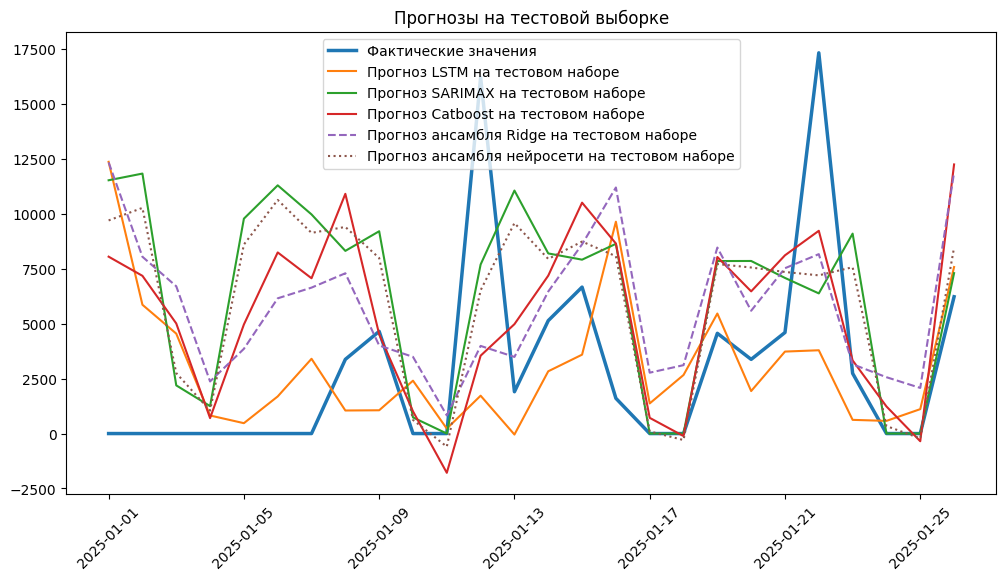

In [66]:
# посмотрим тестовые прогнозы на графике 
plt.figure(figsize=(12, 6))

plt.plot(y_test.index, y_test.values, label='Фактические значения', linewidth=2.5)
plt.plot(y_test.index, y_test_pred_lstm, label='Прогноз LSTM на тестовом наборе')
plt.plot(y_test.index, y_test_pred_sarimax, label='Прогноз SARIMAX на тестовом наборе')
plt.plot(y_test.index, y_test_pred_cb, label='Прогноз Catboost на тестовом наборе')
plt.plot(y_test.index, forecasts_test['forecast_ridge'], label='Прогноз ансамбля Ridge на тестовом наборе', linestyle='--')
plt.plot(y_test.index, forecasts_test['forecast_nn'], label='Прогноз ансамбля нейросети на тестовом наборе', linestyle=':')

plt.xticks(rotation=45)
plt.title('Прогнозы на тестовой выборке')
plt.legend()
plt.show()


In [67]:
y_test.describe()

count      26.00
mean     3014.08
std      4631.36
min         0.00
25%         0.00
50%       801.84
75%      4589.25
max     17324.52
Name: target_shifted, dtype: float64

In [ ]:
if os.path.exists("comparison.csv"):
    comparison = pd.read_csv("comparison.csv")
else:
    comparison = pd.DataFrame(columns=['fund_id'])

# проверяем, есть ли уже этот фонд
if FUND_ID in comparison['fund_id'].values:
    # обновляем существующую строку
    comparison.loc[comparison['fund_id'] == FUND_ID, '3models_lstm_rmse'] = rmse_test_lstm
    comparison.loc[comparison['fund_id'] == FUND_ID, '3models_lstm_smape'] = smape_test_lstm
    comparison.loc[comparison['fund_id'] == FUND_ID, '3models_lstm_mase'] = mase_test_lstm
    comparison.loc[comparison['fund_id'] == FUND_ID, '3models_sarimax_rmse'] = rmse_test_sarimax
    comparison.loc[comparison['fund_id'] == FUND_ID, '3models_sarimax_smape'] = smape_test_sarimax
    comparison.loc[comparison['fund_id'] == FUND_ID, '3models_sarimax_mase'] = mase_test_sarimax
    comparison.loc[comparison['fund_id'] == FUND_ID, '3models_catboost_rmse'] = rmse_test_cb
    comparison.loc[comparison['fund_id'] == FUND_ID, '3models_catboost_smape'] = smape_metrics_test_cb
    comparison.loc[comparison['fund_id'] == FUND_ID, '3models_catboost_mase'] = mase_metrics_test_cb
    comparison.loc[comparison['fund_id'] == FUND_ID, '3models_ens_linear_rmse'] = ens_linear_rmse
    comparison.loc[comparison['fund_id'] == FUND_ID, '3models_ens_linear_smape'] = ens_linear_smape
    comparison.loc[comparison['fund_id'] == FUND_ID, '3models_ens_linear_mase'] = ens_linear_mase
    comparison.loc[comparison['fund_id'] == FUND_ID, '3models_ens_nn_rmse'] = ens_nn_rmse
    comparison.loc[comparison['fund_id'] == FUND_ID, '3models_ens_nn_smape'] = ens_nn_smape
    comparison.loc[comparison['fund_id'] == FUND_ID, '3models_ens_nn_mase'] = ens_nn_mase
else:
    # создаем новую строку для 3 моделей
    new_row = pd.DataFrame({
        'fund_id': [FUND_ID],
        '3models_lstm_rmse': [rmse_test_lstm],
        '3models_lstm_smape': [smape_test_lstm],
        '3models_lstm_mase': [mase_test_lstm],
        '3models_sarimax_rmse': [rmse_test_sarimax],
        '3models_sarimax_smape': [smape_test_sarimax],
        '3models_sarimax_mase': [mase_test_sarimax],
        '3models_catboost_rmse': [rmse_test_cb],
        '3models_catboost_smape': [smape_metrics_test_cb],
        '3models_catboost_mase': [mase_metrics_test_cb],
        '3models_ens_linear_rmse': [ens_linear_rmse],
        '3models_ens_linear_smape': [ens_linear_smape],
        '3models_ens_linear_mase': [ens_linear_mase],
        '3models_ens_nn_rmse': [ens_nn_rmse],
        '3models_ens_nn_smape': [ens_nn_smape],
        '3models_ens_nn_mase': [ens_nn_mase]
    })

    comparison = pd.concat([comparison, new_row], ignore_index=True)

# сохраняем обратно
comparison.to_csv("comparison.csv", index=False)